# Dependencia e independencia lineal, bases y dimensión

En el [Cuaderno8](Cuaderno8.ipynb) definimos espacio vectorial y subespacio, y en su última sección adelantamos las ideas de combinación lineal, generado, independencia y base. En este cuaderno nos detenemos en ellas: son las herramientas que permiten decir *cuántos* vectores hacen falta para describir un espacio y *cuáles* son "verdaderamente distintos".

Usaremos `numpy` para el álgebra numérica (rango, eliminación), `sympy` para trabajar de forma exacta (fracciones, polinomios) y `matplotlib` para visualizar en $\mathbb{R}^2$ y $\mathbb{R}^3$.

In [3]:
import sympy as sp
sp.init_printing()

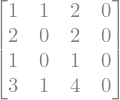

In [6]:
A = sp.Matrix([[1,1,2,0], [2,0,2,0], [1,0,1,0], [3,1,4,0]])
A

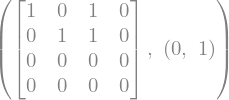

In [7]:
A.rref()

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams["figure.figsize"] = (5, 5)
rng = np.random.default_rng(2026)

## 1. Combinación lineal y conjunto generado

Sea $V$ un espacio vectorial y $v_1,\dots,v_k \in V$. Una **combinación lineal** de estos vectores es cualquier expresión

$$\alpha_1 v_1 + \alpha_2 v_2 + \cdots + \alpha_k v_k, \qquad \alpha_i \in \mathbb{R}.$$

El **conjunto generado** (o *span*) es el conjunto de todas las combinaciones lineales posibles:

$$\operatorname{gen}\{v_1,\dots,v_k\} = \{\alpha_1 v_1 + \cdots + \alpha_k v_k : \alpha_i \in \mathbb{R}\}.$$

Decimos que $\{v_1,\dots,v_k\}$ **genera** a $V$ (o que es un **conjunto generador**) si $\operatorname{gen}\{v_1,\dots,v_k\} = V$.

**Hechos básicos:**

- $\operatorname{gen}\{v_1,\dots,v_k\}$ es siempre un subespacio de $V$ (es cerrado bajo suma y producto por escalar, por construcción).
- $w \in \operatorname{gen}\{v_1,\dots,v_k\}$ si y solo si el sistema lineal $\alpha_1 v_1 + \cdots + \alpha_k v_k = w$ tiene **al menos una** solución para $\alpha_1,\dots,\alpha_k$.

In [2]:
# Es w combinacion lineal de v1, v2? Resolvemos  [v1 v2] alpha = w
v1 = np.array([1.0, 0.0, 1.0])
v2 = np.array([1.0, -1.0, 2.0])
w  = np.array([3.0, -1.0, 4.0])

A = np.column_stack([v1, v2])
sol, res, rank, sv = np.linalg.lstsq(A, w, rcond=None)
reconstruido = A @ sol
es_cl = np.allclose(reconstruido, w)

print("alpha, beta =", sol)
print("alpha*v1 + beta*v2 =", reconstruido)
print("Es w combinacion lineal de v1, v2?", es_cl)

# Con sympy, de forma exacta (fracciones), resolviendo el sistema
alpha, beta = sp.symbols("alpha beta")
V1, V2, W = sp.Matrix(v1), sp.Matrix(v2), sp.Matrix(w)
sistema = alpha * V1 + beta * V2 - W
sol_exacta = sp.solve(list(sistema), [alpha, beta])
print("\nSolucion exacta:", sol_exacta)

alpha, beta = [2. 1.]
alpha*v1 + beta*v2 = [ 3. -1.  4.]
Es w combinacion lineal de v1, v2? True

Solucion exacta: {alpha: 2.00000000000000, beta: 1.00000000000000}


### 1.1 El generado como subespacio: rectas y planos por el origen

En $\mathbb{R}^3$, $\operatorname{gen}\{v\}$ (con $v\neq 0$) es la **recta** por el origen con dirección $v$; $\operatorname{gen}\{u,v\}$ (con $u,v$ no paralelos) es el **plano** por el origen que contiene a $u$ y a $v$. Esto conecta directamente con lo visto en el [Cuaderno6](Cuaderno6.ipynb) y el [Cuaderno7](Cuaderno7.ipynb).

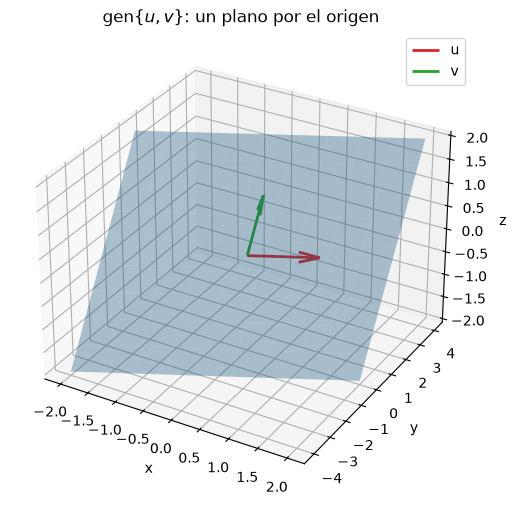

In [3]:
u = np.array([1.0, 1.0, 0.0])
v = np.array([0.0, 1.0, 1.0])

s, t = np.meshgrid(np.linspace(-2, 2, 10), np.linspace(-2, 2, 10))
plano = s[..., None] * u + t[..., None] * v

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(plano[..., 0], plano[..., 1], plano[..., 2], alpha=0.35, color="tab:blue")
ax.quiver(0, 0, 0, *u, color="tab:red", linewidth=2, label="u")
ax.quiver(0, 0, 0, *v, color="tab:green", linewidth=2, label="v")
ax.set_title(r"$\mathrm{gen}\{u,v\}$: un plano por el origen")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend()
plt.show()

## 2. Dependencia e independencia lineal

$\{v_1,\dots,v_k\}$ es **linealmente independiente (LI)** si la única combinación lineal que produce el vector cero es la trivial:

$$\alpha_1 v_1 + \cdots + \alpha_k v_k = \mathbf{0} \quad \Longrightarrow \quad \alpha_1 = \cdots = \alpha_k = 0.$$

Si existe alguna combinación **no trivial** (algún $\alpha_i \neq 0$) que da $\mathbf{0}$, el conjunto es **linealmente dependiente (LD)**.

**Equivalencias útiles (para $k\ge 2$):**

- $\{v_1,\dots,v_k\}$ es LD $\iff$ al menos uno de los $v_i$ es combinación lineal de los demás.
- En particular, dos vectores son LD $\iff$ son **paralelos** (uno es múltiplo escalar del otro).
- Si $\mathbf{0}$ está entre los $v_i$, el conjunto es automáticamente LD (tómese $\alpha_i=1$ en el cero y $0$ en los demás).
- Todo subconjunto de un conjunto LI es LI; todo superconjunto de un conjunto LD es LD.

### 2.1 Criterio matricial

En $\mathbb{R}^n$, formamos la matriz $A$ cuyas columnas son $v_1,\dots,v_k$. Entonces

$$\{v_1,\dots,v_k\} \text{ es LI} \iff \operatorname{rango}(A) = k \iff \text{el sistema } A\alpha=\mathbf{0} \text{ solo tiene la solución trivial}.$$

Si $k=n$, esto equivale a $\det(A) \neq 0$.

In [4]:
def es_li(vectores, tol=1e-9):
    # vectores: lista de arreglos 1D. Devuelve (es_LI, rango, k)
    A = np.column_stack(vectores)
    rango = np.linalg.matrix_rank(A, tol=tol)
    k = len(vectores)
    return rango == k, rango, k


casos = {
    "LI en R^3":          [np.array([1., 2., 3.]), np.array([0., 1., 4.]), np.array([5., 6., 0.])],
    "LD en R^3 (v2=2v1)": [np.array([1., 2., 3.]), np.array([2., 4., 6.]), np.array([0., 1., 1.])],
    "2 paralelos en R^2": [np.array([2., -1.]), np.array([-4., 2.])],
    "contiene al 0":      [np.array([1., 0., 0.]), np.array([0., 0., 0.]), np.array([0., 1., 0.])],
    "4 vectores en R^3":  [np.array([1., 0., 0.]), np.array([0., 1., 0.]),
                            np.array([0., 0., 1.]), np.array([1., 1., 1.])],
}

for nombre, vs in casos.items():
    li, rango, k = es_li(vs)
    print(f"{nombre:22s} -> rango={rango}, k={k}  =>  {'LI' if li else 'LD'}")

LI en R^3              -> rango=3, k=3  =>  LI
LD en R^3 (v2=2v1)     -> rango=2, k=3  =>  LD
2 paralelos en R^2     -> rango=1, k=2  =>  LD
contiene al 0          -> rango=2, k=3  =>  LD
4 vectores en R^3      -> rango=3, k=4  =>  LD


### 2.2 Encontrar la relación de dependencia

Cuando un conjunto es LD, suele interesar la combinación no trivial explícita. Resolvemos $A\alpha = \mathbf{0}$ con `sympy` para obtener el espacio nulo exacto (ver también el [Cuaderno5](Cuaderno5.ipynb) sobre sistemas lineales).

In [5]:
V = sp.Matrix([[1, 2, 0],
               [2, 4, 1],
               [3, 6, 1]]).T   # columnas = v1, v2, v3

nulo = V.nullspace()
print("Matriz [v1 v2 v3]:")
sp.pprint(V)
print("\nEspacio nulo de A alpha = 0:")
for base in nulo:
    sp.pprint(base.T)

if nulo:
    alpha = nulo[0]
    v1, v2, v3 = V[:, 0], V[:, 1], V[:, 2]
    combo = alpha[0]*v1 + alpha[1]*v2 + alpha[2]*v3
    print("\nCon alpha =", alpha.T, " se obtiene  alpha1 v1 + alpha2 v2 + alpha3 v3 =", combo.T)

Matriz [v1 v2 v3]:
⎡1  2  3⎤
⎢       ⎥
⎢2  4  6⎥
⎢       ⎥
⎣0  1  1⎦

Espacio nulo de A alpha = 0:
[-1  -1  1]

Con alpha = Matrix([[-1, -1, 1]])  se obtiene  alpha1 v1 + alpha2 v2 + alpha3 v3 = Matrix([[0, 0, 0]])


### 2.3 Independencia en $P_n$ y en $M_{m\times n}$

El mismo criterio se aplica en cualquier espacio de dimensión finita: se pasa a **coordenadas** respecto de una base conocida (por ejemplo $\{1,x,x^2,\dots\}$ en $P_n$, o $\{E_{ij}\}$ en $M_{m\times n}$) y se calcula el rango de la matriz de coordenadas.

In [6]:
x = sp.symbols("x")

def coords_poli(p, n):
    p = sp.expand(p)
    return [p.coeff(x, k) for k in range(n + 1)]

polis = [1 + x, x + x**2, 3 + 4*x + x**2]
M = sp.Matrix([coords_poli(p, 2) for p in polis])
print("Coordenadas en {1, x, x^2}:")
sp.pprint(M)
print("rango =", M.rank(), " de", len(polis), "polinomios ->", "LI" if M.rank() == len(polis) else "LD")

# Matrices 2x2 vistas como vectores de R^4 (coordenadas en la base E11,E12,E21,E22)
A1 = np.array([[1, 0], [0, 1]])
A2 = np.array([[0, 1], [1, 0]])
A3 = np.array([[1, 1], [1, 1]])
coords_mat = np.array([A.flatten() for A in (A1, A2, A3)]).T
print("\nRango de [A1 A2 A3] (como vectores en R^4):", np.linalg.matrix_rank(coords_mat),
      " de 3 matrices ->", "LI" if np.linalg.matrix_rank(coords_mat) == 3 else "LD",
      " (en efecto A3 = A1 + A2)")

Coordenadas en {1, x, x^2}:
⎡1  1  0⎤
⎢       ⎥
⎢0  1  1⎥
⎢       ⎥
⎣3  4  1⎦
rango = 2  de 3 polinomios -> LD

Rango de [A1 A2 A3] (como vectores en R^4): 2  de 3 matrices -> LD  (en efecto A3 = A1 + A2)


### 2.4 Interpretación geométrica en $\mathbb{R}^2$ y $\mathbb{R}^3$

- En $\mathbb{R}^2$: dos vectores son LD si y solo si son paralelos (el paralelogramo que forman tiene área $0$).
- En $\mathbb{R}^3$: tres vectores son LD si y solo si son coplanares (el paralelepípedo que forman tiene volumen $0$, es decir $\det = 0$).

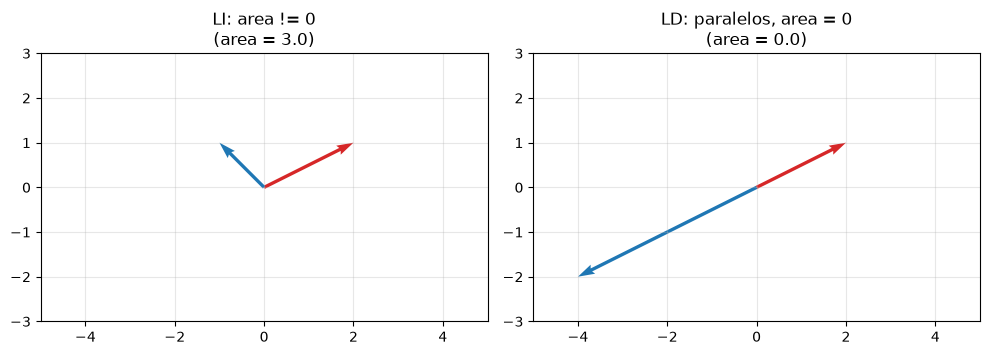

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

pares = [
    (np.array([2., 1.]), np.array([-1., 1.]), "LI: area != 0"),
    (np.array([2., 1.]), np.array([-4., -2.]), "LD: paralelos, area = 0"),
]
for ax, (u, v, titulo) in zip(axes, pares):
    ax.quiver(0, 0, *u, angles="xy", scale_units="xy", scale=1, color="tab:red")
    ax.quiver(0, 0, *v, angles="xy", scale_units="xy", scale=1, color="tab:blue")
    area = abs(u[0]*v[1] - u[1]*v[0])
    ax.set_xlim(-5, 5); ax.set_ylim(-3, 3); ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_title(f"{titulo}\n(area = {area:.1f})")
plt.tight_layout(); plt.show()

## 3. Base y dimensión

$\mathcal{B} = \{v_1,\dots,v_k\} \subset V$ es una **base** de $V$ si:

1. $\mathcal{B}$ genera a $V$: $\operatorname{gen}\mathcal{B} = V$, y
2. $\mathcal{B}$ es linealmente independiente.

**Teorema (buena definición de la dimensión).** Todas las bases de un mismo espacio vectorial (de dimensión finita) tienen el **mismo número** de elementos. Ese número es la **dimensión**, $\dim V$.

**Consecuencias muy usadas** (con $\dim V = n$):

- Cualquier conjunto LI con $n$ vectores ya es una base (no hace falta verificar que genera).
- Cualquier conjunto generador con $n$ vectores ya es una base (no hace falta verificar independencia).
- Más de $n$ vectores en $V$ siempre son LD.
- Menos de $n$ vectores nunca pueden generar $V$.

### 3.1 Coordenadas respecto a una base

Si $\mathcal{B}=\{v_1,\dots,v_n\}$ es base de $V$, todo $w\in V$ se escribe de **forma única** como $w = c_1v_1+\cdots+c_nv_n$. El vector $[w]_{\mathcal B} = (c_1,\dots,c_n)$ son las **coordenadas** de $w$ en la base $\mathcal B$.

In [8]:
def es_base(vectores, n, tol=1e-9):
    # vectores: lista de k vectores en R^n. Base de R^n si k == n y son LI.
    A = np.column_stack(vectores)
    k = len(vectores)
    rango = np.linalg.matrix_rank(A, tol=tol)
    return (k == n and rango == n), rango, k


B1 = [np.array([1., 1.]), np.array([1., -1.])]
B2 = [np.array([1., 1.]), np.array([2., 2.])]
B3 = [np.array([1., 0.]), np.array([0., 1.]), np.array([1., 1.])]

for nombre, B in [("B1", B1), ("B2", B2), ("B3 (3 vectores en R^2)", B3)]:
    ok, rango, k = es_base(B, n=2)
    print(f"{nombre}: rango={rango}, k={k}  ->  {'ES base de R^2' if ok else 'NO es base de R^2'}")

# Coordenadas de w = (5, 1) en la base B1 = {(1,1),(1,-1)}
w = np.array([5.0, 1.0])
A = np.column_stack(B1)
coord = np.linalg.solve(A, w)
print(f"\n[w]_B1 = {coord}   (comprobacion: {coord[0]}*(1,1) + {coord[1]}*(1,-1) = {A @ coord})")

B1: rango=2, k=2  ->  ES base de R^2
B2: rango=1, k=2  ->  NO es base de R^2
B3 (3 vectores en R^2): rango=2, k=3  ->  NO es base de R^2

[w]_B1 = [3. 2.]   (comprobacion: 3.0*(1,1) + 2.0*(1,-1) = [5. 1.])


### 3.2 Cambio de base como cambio de coordenadas

Si $\mathcal B=\{v_1,\dots,v_n\}$ es base de $\mathbb{R}^n$ y $P=[v_1\ \cdots\ v_n]$ es la matriz con esos vectores como columnas, entonces para todo $w$:

$$w = P\,[w]_{\mathcal B} \qquad\Longleftrightarrow\qquad [w]_{\mathcal B} = P^{-1} w.$$

$P$ es invertible precisamente porque $\mathcal B$ es LI (columnas de rango completo).

In [9]:
P = np.column_stack(B1)
print("P =\n", P)
print("det(P) =", np.linalg.det(P), " (no nulo -> P es invertible -> B1 es base)")

w = np.array([5.0, 1.0])
coord_via_inversa = np.linalg.inv(P) @ w
print("\n[w]_B1 via P^{-1} w =", coord_via_inversa)
print("Coincide con np.linalg.solve:", np.allclose(coord_via_inversa, np.linalg.solve(P, w)))

P =
 [[ 1.  1.]
 [ 1. -1.]]
det(P) = -2.0  (no nulo -> P es invertible -> B1 es base)

[w]_B1 via P^{-1} w = [3. 2.]
Coincide con np.linalg.solve: True


## 4. Extender un conjunto LI a una base

Si $\{v_1,\dots,v_k\}$ es LI en $V$ con $\dim V = n$ y $k<n$, siempre se puede **completar** con $n-k$ vectores (por ejemplo, de la base canónica) hasta obtener una base de $V$. El truco práctico: se agregan candidatos de uno en uno y se conservan solo los que aumentan el rango.

In [10]:
def completar_base(vectores_li, candidatos, n):
    base = list(vectores_li)
    rango_actual = np.linalg.matrix_rank(np.column_stack(base))
    for c in candidatos:
        if rango_actual == n:
            break
        prueba = np.column_stack(base + [c])
        r = np.linalg.matrix_rank(prueba)
        if r > rango_actual:
            base.append(c)
            rango_actual = r
    return base


li_inicial = [np.array([1.0, 2.0, 0.0])]
canonicos = [np.array([1., 0., 0.]), np.array([0., 1., 0.]), np.array([0., 0., 1.])]

base_completa = completar_base(li_inicial, canonicos, n=3)
print("Base completada:")
for v in base_completa:
    print(" ", v)
print("rango final =", np.linalg.matrix_rank(np.column_stack(base_completa)), " (debe ser 3)")

Base completada:
  [1. 2. 0.]
  [1. 0. 0.]
  [0. 0. 1.]
rango final = 3  (debe ser 3)


## 5. Base y dimensión de un subespacio dado por ecuaciones

Un subespacio $W\subseteq \mathbb{R}^n$ suele describirse de dos formas:

- **implícita**: como solución de un sistema homogéneo $A x = \mathbf{0}$ (ver [Cuaderno5](Cuaderno5.ipynb));
- **paramétrica**: como $\operatorname{gen}\{v_1,\dots,v_k\}$.

Para pasar de la forma implícita a una base, basta resolver el sistema homogéneo: el **espacio nulo** de $A$ es exactamente $W$, y una base de ese espacio nulo (una por cada variable libre) es una base de $W$. Por el **teorema rango-nulidad**,

$$\dim W = n - \operatorname{rango}(A).$$

In [11]:
# W = {(x,y,z,w) : x + 2y - z + w = 0,  2x + 4y - z + 3w = 0}  subespacio de R^4
A = sp.Matrix([[1, 2, -1, 1],
               [2, 4, -1, 3]])

base_W = A.nullspace()
print("rango(A) =", A.rank(), "  n =", A.cols, "  dim W = n - rango =", A.cols - A.rank())
print("\nBase de W (espacio nulo de A):")
for b in base_W:
    sp.pprint(b.T)

# Verificacion: cada vector de la base satisface A v = 0
for b in base_W:
    print("A @ v =", (A * b).T, " (debe ser el vector cero)")

rango(A) = 2   n = 4   dim W = n - rango = 2

Base de W (espacio nulo de A):
[-2  1  0  0]
[-2  0  -1  1]
A @ v = Matrix([[0, 0]])  (debe ser el vector cero)
A @ v = Matrix([[0, 0]])  (debe ser el vector cero)


## 6. Suma y suma directa de subespacios

Si $U,W$ son subespacios de $V$, su **suma** es
$$U+W = \{u+w : u\in U,\ w\in W\},$$
que también es un subespacio, y satisface la fórmula de **Grassmann**:
$$\dim(U+W) = \dim U + \dim W - \dim(U\cap W).$$

Cuando $U\cap W = \{\mathbf{0}\}$, la suma se llama **suma directa**, se escribe $U\oplus W$, y entonces $\dim(U\oplus W)=\dim U+\dim W$: todo vector de $U+W$ se descompone de **forma única** como $u+w$.

In [12]:
# U = plano xy (z=0), W = eje z, en R^3: suma directa U (+) W = R^3
U = sp.Matrix([[1, 0, 0], [0, 1, 0]]).T   # columnas generan U
Wsp = sp.Matrix([[0, 0, 1]]).T            # columna genera W

interseccion = sp.Matrix.hstack(U, Wsp).nullspace()  # combinaciones que dan 0 -> mide dependencia, no interseccion directa
# Mejor: interseccion via sistema  U a = W b
a1, a2, b1 = sp.symbols("a1 a2 b1")
punto_U = U * sp.Matrix([a1, a2])
punto_W = Wsp * sp.Matrix([b1])
sol = sp.solve(list(punto_U - punto_W), [a1, a2, b1])
print("Solucion del sistema U a = W b:", sol, " -> interseccion = {0}, dim(U inter W) = 0")

dimU, dimW = 2, 1
dim_suma = dimU + dimW - 0
print(f"\ndim U = {dimU}, dim W = {dimW}  =>  dim(U (+) W) = {dim_suma}  (= dim R^3, suma directa)")

# Un caso NO directo: U = plano xy, W' = plano xz (se cortan en el eje x)
Wp = sp.Matrix([[1, 0, 0], [0, 0, 1]]).T
c1, c2, d1, d2 = sp.symbols("c1 c2 d1 d2")
eq = U*sp.Matrix([c1, c2]) - Wp*sp.Matrix([d1, d2])
sol2 = sp.solve(list(eq), [c1, c2, d1, d2], dict=True)
print("\nU (plano xy) y W' (plano xz) se cortan en una recta (el eje x):")
print("solucion parametrica del sistema:", sol2)

Solucion del sistema U a = W b: {a1: 0, a2: 0, b1: 0}  -> interseccion = {0}, dim(U inter W) = 0

dim U = 2, dim W = 1  =>  dim(U (+) W) = 3  (= dim R^3, suma directa)

U (plano xy) y W' (plano xz) se cortan en una recta (el eje x):
solucion parametrica del sistema: [{c1: d1, c2: 0, d2: 0}]


## 7. Resumen

- Una **combinación lineal** de $v_1,\dots,v_k$ es $\alpha_1v_1+\cdots+\alpha_kv_k$; el **generado** $\operatorname{gen}\{v_1,\dots,v_k\}$ (todas esas combinaciones) es siempre un subespacio.
- $\{v_1,\dots,v_k\}$ es **linealmente independiente** si $\alpha_1v_1+\cdots+\alpha_kv_k=\mathbf 0 \implies$ todos los $\alpha_i=0$; en caso contrario es **dependiente**.
- En $\mathbb{R}^n$, la independencia se decide con el **rango** de la matriz cuyas columnas son los $v_i$: LI $\iff$ rango $=k$.
- Una **base** es un conjunto generador y LI; todas las bases de un espacio tienen el mismo tamaño, la **dimensión**.
- Todo vector se escribe de forma **única** en coordenadas respecto a una base; cambiar de base es multiplicar por $P$ o por $P^{-1}$.
- Todo conjunto LI se puede **completar** a una base; toda base de un subespacio dado por $Ax=0$ sale del **espacio nulo** de $A$, y $\dim W = n - \operatorname{rango}(A)$.
- La fórmula de **Grassmann** $\dim(U+W)=\dim U+\dim W-\dim(U\cap W)$ gobierna cómo se combinan subespacios; si $U\cap W=\{\mathbf 0\}$ la suma es **directa**.

## 8. Ejercicios

Resuelve a mano y verifica tus respuestas con `numpy`/`sympy` en la celda final.

### A. Combinación lineal y generado

1. ¿Es $(4,1,5)$ combinación lineal de $(1,1,1)$ y $(1,0,2)$? Si lo es, dé los coeficientes.
2. Describa $\operatorname{gen}\{(1,2),(3,6)\}$ geométricamente. ¿Es todo $\mathbb{R}^2$?
3. ¿El polinomio $p(x)=5+3x-x^2$ está en $\operatorname{gen}\{1+x,\ x-x^2,\ 1+x^2\}$ dentro de $P_2$?
4. Muestre que $\operatorname{gen}\{v_1,\dots,v_k\}$ es el subespacio **más pequeño** que contiene a $v_1,\dots,v_k$.

### B. Independencia y dependencia

5. Determine si $\{(1,-1,2),(2,1,0),(0,-3,4)\}$ es LI en $\mathbb{R}^3$. Si es LD, halle la relación de dependencia.
6. ¿Para qué valores de $k$ es LI el conjunto $\{(1,2,k),(0,1,3),(2,4,1)\}$?
7. Muestre que $\{1,\ \cos^2 x,\ \sin^2 x\}$ es LD en el espacio de funciones $F(\mathbb R,\mathbb R)$ (piense en una identidad trigonométrica).
8. Muestre que $\{e^x, e^{2x}\}$ es LI en $F(\mathbb R,\mathbb R)$ (evalúe la combinación y su derivada en $x=0$).
9. Si $\{v_1,v_2,v_3\}$ es LI, ¿es $\{v_1+v_2,\ v_2+v_3,\ v_1+v_3\}$ necesariamente LI? Justifique.
10. Las matrices $\begin{psmallmatrix}1&0\\0&0\end{psmallmatrix}$, $\begin{psmallmatrix}0&1\\1&0\end{psmallmatrix}$, $\begin{psmallmatrix}0&0\\0&1\end{psmallmatrix}$, $\begin{psmallmatrix}2&1\\1&1\end{psmallmatrix}$: ¿son LI en $M_{2\times2}$?

### C. Bases y dimensión

11. ¿Es $\{(1,1,0),(0,1,1),(1,0,1)\}$ una base de $\mathbb{R}^3$? Halle las coordenadas de $(2,-1,3)$ en esa base si lo es.
12. Halle una base y la dimensión de $W=\{(x,y,z,w): x-y+z=0,\ y-w=0\}\subset\mathbb{R}^4$.
13. Complete $\{(1,1,1,0)\}$ a una base de $\mathbb{R}^4$ usando vectores canónicos.
14. Dé una base de $M_{2\times 2}(\mathbb R)$ formada solo por matrices **simétricas** e indique su dimensión.
15. ¿Cuál es la dimensión del subespacio de $P_3$ formado por los polinomios con $p(0)=0$? Dé una base.
16. Sean $B_1=\{(1,0),(0,1)\}$ y $B_2=\{(1,1),(1,-1)\}$ bases de $\mathbb{R}^2$. Halle la matriz de cambio de base de $B_2$ a $B_1$ y úsela para escribir $(3,5)$ en la base $B_2$.
17. En el espacio $\mathbb{R}^+$ (con $u\oplus v=uv$, $\alpha\odot u=u^\alpha$) del [Cuaderno8](Cuaderno8.ipynb), justifique por qué $\dim \mathbb{R}^+=1$ y por qué $\{5,\,25\}$ es LD ahí (aunque $5$ y $25$ no sean "paralelos" en el sentido usual).

### D. Suma y suma directa

18. Sean $U=\operatorname{gen}\{(1,0,0),(0,1,0)\}$ y $W=\operatorname{gen}\{(1,1,1)\}$ en $\mathbb{R}^3$. Muestre que $\mathbb{R}^3=U\oplus W$.
19. Sean $U=\{(x,y,z):x=y\}$ y $W=\{(x,y,z):y=z\}$ en $\mathbb{R}^3$. Halle $U\cap W$, $\dim(U+W)$ y diga si la suma es directa.
20. Dé un ejemplo de dos subespacios de $\mathbb{R}^2$, distintos de $\{0\}$ y de $\mathbb{R}^2$, cuya suma sea directa.
21. Demuestre que si $U\oplus W = V$, todo $v\in V$ se escribe de forma única como $u+w$ con $u\in U,\ w\in W$.

In [13]:
# Espacio para verificar tus respuestas.
# Ejemplo (ejercicio 5):
# vs = [np.array([1., -1., 2.]), np.array([2., 1., 0.]), np.array([0., -3., 4.])]
# print(es_li(vs))